    Разработка методов гибридизации машинного обучения и символьной регрессии для построения адаптивных моделей принятия решений

c:\Users\Ivan\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 7.810e+04
Progress: 413 / 9300 total iterations (4.441%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.802e+08  0.000e+00  y = 39146
2           2.077e+07  -0.000e+00  y = exp(x₁₅)
3           4.020e+06  8.130e-01  y = x₁₀ + x₂₂
5           3.629e+06  -0.000e+00  y = (x₂₂ * 2.5411) + x₁₀
7           3.019e+06  -0.000e+00  y = x₆ - (x₁ * (x₁₈ * 0.72818))
9           3.010e+06  -0.000e+00  y = x₆ + (((-2520.4 - x₁) * x₁₈) / 1.4461)
11          2.996e+06  -0.000e+00  y = x₆ + (-0.90929 - ((x₁₈ * (x₁ - x₂₂)) / 1.3812))
12          2.889e+06  -0.000e+00  y = x₆ - ((((x₈ * x₁₈) - sin(x₂₁)) / 1.3608) + x₂₁)
13          2.755e+06  -0.000e+00  y = x₆ - (((x₁₈ * x₁) / 1.5193) + ((x₂₁ + 35.142) - 3.675...
                                       ))
15     

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Hybrid MAE: 1471.7768067501631
Hybrid RMSE: 1993.2264709536719
Hybrid R2: 0.9798490679920075
Hybrid MAPE: 1.546967769933565


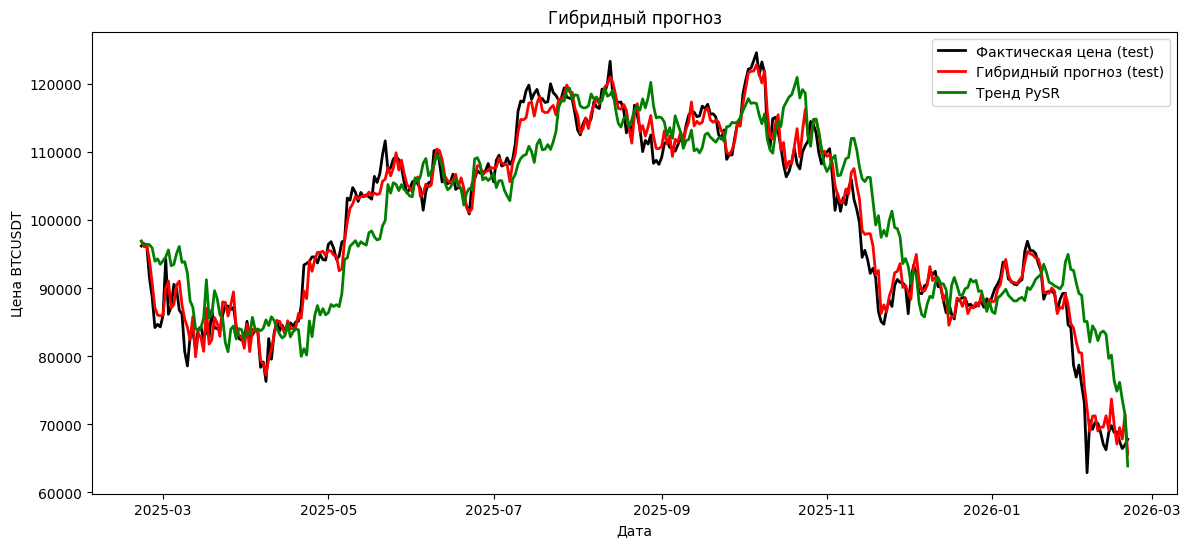

  - outputs\20260411_154310_RHdCzw\hall_of_fame.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from pysr import PySRRegressor

df = pd.read_csv("../data/BTCUSDT_linear_D_2018-01-01_to_2026.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
date_col = df["date"]
for lag in [1, 2, 3, 7, 14]:
    df[f"lag_{lag}"] = df["close"].shift(lag)
df["ma_7"] = df["close"].rolling(7).mean().shift(1)
df["ma_14"] = df["close"].rolling(14).mean().shift(1)
df["vol_7"] = df["close"].rolling(7).std().shift(1)
df["vol_14"] = df["close"].rolling(14).std().shift(1)
df["log_close"] = np.log(df["close"])
df["log_return_1"] = df["log_close"].diff().shift(1)
df["log_return_7"] = df["log_close"].diff(7).shift(1)
df["log_return_14"] = df["log_close"].diff(14).shift(1)
df["momentum_7"] = df["close"] / df["close"].shift(7) - 1
df["momentum_14"] = df["close"] / df["close"].shift(14) - 1

def trend_slope(x):
    y = np.array(x)
    x_idx = np.arange(len(x))
    return np.polyfit(x_idx, y, 1)[0]

df["trend_7"] = df["close"].rolling(7).apply(trend_slope).shift(1)
df["trend_14"] = df["close"].rolling(14).apply(trend_slope).shift(1)
df["t"] = np.arange(len(df))
df["dow_sin"] = np.sin(2 * np.pi * df["date"].dt.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["date"].dt.dayofweek / 7)
df["trend_target"] = df["close"].rolling(30).mean().shift(1)

df = df.drop(columns=["date"])
object_cols = df.select_dtypes(include=["object"]).columns
df = df.drop(columns=object_cols)
df = df.dropna().reset_index(drop=True)

target = "close"
trend_target = df["trend_target"]
features = [c for c in df.columns if c not in [target, "trend_target"]]

X = df[features]
y = df[target]

test_size = 365
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]
trend_train, trend_test = trend_target.iloc[:-test_size], trend_target.iloc[-test_size:]
test_dates = date_col.iloc[-test_size:]
model_pysr = PySRRegressor(niterations=300, maxsize=16, maxdepth=6,
                           model_selection="best", unary_operators=["sin", "cos", "exp", "log"],
                           binary_operators=["+", "-", "*", "/"])
model_pysr.fit(X_train.values, trend_train.values)

trend_pred_train = model_pysr.predict(X_train.values)
trend_pred_test = model_pysr.predict(X_test.values)
y_train_detrended = y_train.values - trend_pred_train

model_xgb = XGBRegressor(n_estimators=1500, learning_rate=0.02, max_depth=8,
                         subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror")
model_xgb.fit(X_train, y_train_detrended)

oscillation_pred_test = model_xgb.predict(X_test)
y_pred_test_hybrid = trend_pred_test + oscillation_pred_test
errors = y_test.values - y_pred_test_hybrid

mae = mean_absolute_error(y_test, y_pred_test_hybrid)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_hybrid))
r2 = r2_score(y_test, y_pred_test_hybrid)
mape = np.mean(np.abs((y_test - y_pred_test_hybrid) / y_test)) * 100

print("Hybrid MAE:", mae)
print("Hybrid RMSE:", rmse)
print("Hybrid R2:", r2)
print("Hybrid MAPE:", mape)

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test.values, label="Фактическая цена (test)", linewidth=2, color="black")
plt.plot(test_dates, y_pred_test_hybrid, label="Гибридный прогноз (test)", linewidth=2, color="red")
plt.plot(test_dates, trend_pred_test, label="Тренд PySR", linewidth=2, color="green")
plt.title("Гибридный прогноз")
plt.xlabel("Дата")
plt.ylabel("Цена BTCUSDT")
plt.legend()
plt.show()